# train.ipynb — 訓練 + tuning + calibration + metadata + SHAP (Version 3)

此 notebook 在你已有的 `train_features_cutoffed.csv` 基礎上執行：
1) 建立模型 pipeline（LR / RF / LightGBM），LightGBM 已設 verbose=-1 與 force_col_wise=True 以抑制訊息。
2) 用 RandomizedSearchCV 對 RF 與 LGB 做 hyperparameter tuning（scoring=average_precision）。
3) 選最佳模型並示範 CalibratedClassifierCV（機率校正）、threshold 選擇與 precision@k輸出 top-K。
4) 儲存最佳模型、校正模型、feature list、訓練 / 評估指標到 train_artifacts/ 並生成 metadata.json。
5) 執行 SHAP 分析並儲存 summary 圖與 feature importance CSV。

執行建議：重啟 kernel，從上到下依序執行 cell（tuning 可能需要較長時間）。

In [1]:
# Cell: 從 acct_transaction_predict.csv 產生 acct_predict_features.csv，並用模型打分
import os
import pandas as pd
import numpy as np
import joblib

# ----- 可調參數 -----
ACCT_PRED_CSV = "acct_predict.csv"                    # 4780 帳戶清單 (acct, label)
PRED_TXN_CSV = "acct_transaction_predict.csv"         # 369232 筆交易 (來自母集)
TRAIN_FEATURES_FILE = "train_features_cutoffed.csv"   # 用來取得訓練時 feature 欄位
OUT_PRED_FEATURES = "acct_predict_features.csv"
OUT_PRED_RESULT = "acct_predict_result.csv"
BASE_DATE = globals().get('BASE_DATE', '2020-01-01')   # 若你在 notebook 已定義 BASE_DATE 會使用它
PRED_CUTOFF_DATE = None   # None = 使用各帳戶最後可見交易時間；或設定固定 pd.Timestamp('YYYY-MM-DD')
USE_CALIBRATED_MODEL_IF_EXISTS = True
MODEL_PATH = "train_artifacts/best_model.joblib"
CALIB_MODEL_PATH = "train_artifacts/calibrated_model.joblib"
# ----------------------

base = pd.to_datetime(BASE_DATE)

# 讀入帳戶與交易
acct_pred = pd.read_csv(ACCT_PRED_CSV, dtype=str).fillna("")
tx_pred = pd.read_csv(PRED_TXN_CSV, dtype=str).fillna("")

print("acct_predict rows:", len(acct_pred), " predict txn rows:", len(tx_pred))

# 解析 txn_date + txn_time -> dt（與訓練時同樣邏輯）
def build_dt_predict(df):
    df = df.copy()
    df['txn_date_int'] = pd.to_numeric(df.get('txn_date',''), errors='coerce')
    df['txn_time'] = df.get('txn_time','').replace('', '00:00:00')
    # safe time to timedelta
    def safe_time_to_timedelta(t):
        try:
            return pd.to_timedelta(t)
        except:
            return pd.to_timedelta('00:00:00')
    df['time_only'] = df['txn_time'].apply(safe_time_to_timedelta)
    df['dt'] = df['txn_date_int'].apply(lambda x: (base + pd.Timedelta(days=int(x)-1)) if not pd.isna(x) else pd.NaT) + df['time_only'].fillna(pd.Timedelta(seconds=0))
    return df

tx_pred = build_dt_predict(tx_pred)
print("parsed dt non-null:", tx_pred['dt'].notna().sum(), "/", len(tx_pred))

# 取得訓練時用的 feature 欄位（若找不到就用 acct_features 計算回傳的 keys）
if os.path.exists(TRAIN_FEATURES_FILE):
    train_feat_df = pd.read_csv(TRAIN_FEATURES_FILE, dtype=str).fillna("")
    # 讀取欄位但去掉 acct,label
    train_cols = [c for c in train_feat_df.columns if c not in ('acct','label')]
    print("Loaded train feature columns (count):", len(train_cols))
else:
    train_cols = None
    print("找不到", TRAIN_FEATURES_FILE, "將用 acct_features 的輸出自動對齊特徵。")

# 特徵化函式：優先使用 notebook 中的 acct_features，否則用 fallback
def fallback_acct_features(df_acct, acct_id=None):
    feat = {}
    feat['total_txns'] = len(df_acct)
    feat['in_txns'] = int((df_acct['to_acct']==acct_id).sum()) if (acct_id is not None and 'to_acct' in df_acct.columns) else int((df_acct['to_acct'].notna()).sum()) if 'to_acct' in df_acct.columns else 0
    feat['out_txns'] = int((df_acct['from_acct']==acct_id).sum()) if (acct_id is not None and 'from_acct' in df_acct.columns) else int((df_acct['from_acct'].notna()).sum()) if 'from_acct' in df_acct.columns else 0
    feat['sum_in_amt'] = float(df_acct.loc[df_acct['to_acct']==acct_id, 'txn_amt'].astype(float).sum()) if ('txn_amt' in df_acct.columns and acct_id is not None) else (float(df_acct['txn_amt'].astype(float).sum()) if 'txn_amt' in df_acct.columns else 0.0)
    feat['sum_out_amt'] = float(df_acct.loc[df_acct['from_acct']==acct_id, 'txn_amt'].astype(float).sum()) if ('txn_amt' in df_acct.columns and acct_id is not None) else (float(df_acct['txn_amt'].astype(float).sum()) if 'txn_amt' in df_acct.columns else 0.0)
    feat['max_txn_amt'] = float(df_acct['txn_amt'].astype(float).max()) if ('txn_amt' in df_acct.columns and len(df_acct)>0) else 0.0
    cps = []
    if 'from_acct' in df_acct.columns:
        cps.extend(df_acct['from_acct'].astype(str).tolist())
    if 'to_acct' in df_acct.columns:
        cps.extend(df_acct['to_acct'].astype(str).tolist())
    cps = set([c for c in cps if c and c != acct_id])
    feat['unique_counterparties'] = len(cps)
    return feat

# 計算特徵（若你在 notebook 已有 acct_features，會優先使用）
from tqdm.auto import tqdm
acct_list = acct_pred['acct'].astype(str).unique().tolist()
rows = []
for acct in tqdm(acct_list, desc='計算 predict 帳戶特徵'):
    acct = str(acct)
    df_acct = tx_pred[(tx_pred['from_acct']==acct) | (tx_pred['to_acct']==acct)].copy()
    if df_acct.empty:
        feats = {}
    else:
        # apply cutoff per-account if PRED_CUTOFF_DATE specified; else use all tx (we already have only predict-account tx)
        if PRED_CUTOFF_DATE is not None:
            cutoff = pd.to_datetime(PRED_CUTOFF_DATE)
            df_acct = df_acct[df_acct['dt'] <= cutoff]
    # call user-defined acct_features if exists
    if 'acct_features' in globals():
        try:
            feats = acct_features(df_acct)   # assume returns dict-like
        except Exception as e:
            # fallback
            feats = fallback_acct_features(df_acct, acct_id=acct)
    else:
        feats = fallback_acct_features(df_acct, acct_id=acct)
    feats['acct'] = acct
    rows.append(feats)

pred_feat_df = pd.DataFrame(rows).fillna(0)
print("pred feature df shape:", pred_feat_df.shape)

# 若有 train_cols，對齊欄位順序：增加缺的欄位(0)，刪除多的欄位
if train_cols is not None:
    for c in train_cols:
        if c not in pred_feat_df.columns:
            pred_feat_df[c] = 0
    # keep final cols in same order as train_cols, but keep acct first
    final_cols = ['acct'] + train_cols
    pred_feat_df = pred_feat_df.reindex(columns=[c for c in final_cols if c in pred_feat_df.columns])
else:
    # set train_cols to pred_feat_df columns excluding acct (so next steps know feature names)
    train_cols = [c for c in pred_feat_df.columns if c != 'acct']

# 儲存 acct_predict_features.csv
pred_feat_df.to_csv(OUT_PRED_FEATURES, index=False)
print("Wrote", OUT_PRED_FEATURES, "shape:", pred_feat_df.shape)

# ----------------- 對帳戶打分（若有模型） -----------------
# 優先使用經校正模型（calibrated），其次 use calibrated_model.joblib, else best_model.joblib
model = None
if USE_CALIBRATED_MODEL_IF_EXISTS and os.path.exists(CALIB_MODEL_PATH):
    try:
        model = joblib.load(CALIB_MODEL_PATH)['pipeline'] if isinstance(joblib.load(CALIB_MODEL_PATH), dict) and 'pipeline' in joblib.load(CALIB_MODEL_PATH) else joblib.load(CALIB_MODEL_PATH)
        print("Loaded calibrated model from", CALIB_MODEL_PATH)
    except Exception:
        model = None

if model is None and os.path.exists(MODEL_PATH):
    try:
        model_obj = joblib.load(MODEL_PATH)
        # model_obj may be {'pipeline': pipeline, ...} or pipeline directly
        if isinstance(model_obj, dict) and 'pipeline' in model_obj:
            model = model_obj['pipeline']
        else:
            model = model_obj
        print("Loaded model from", MODEL_PATH)
    except Exception as e:
        print("Failed to load model:", e)
        model = None

if model is not None:
    # align columns
    Xp = pred_feat_df[[c for c in pred_feat_df.columns if c != 'acct']].copy()
    # ensure numeric
    Xp = Xp.astype(float).fillna(0.0)
    # predict_proba if available
    try:
        probs = model.predict_proba(Xp)[:,1]
    except Exception:
        try:
            probs = model.decision_function(Xp)
            # scale to 0-1 with minmax for interpretability (not a probability)
            probs = (probs - probs.min()) / (probs.max() - probs.min() + 1e-12)
        except Exception:
            raise RuntimeError("模型既無 predict_proba 也無 decision_function，無法打分。")
    out_df = pred_feat_df[['acct']].copy()
    out_df['score'] = probs
    # 預設閾值 0.5 轉成 pred_label（可依業務改）
    out_df['pred_label'] = (out_df['score'] >= 0.5).astype(int)
    out_df.to_csv(OUT_PRED_RESULT, index=False)
    print("Wrote", OUT_PRED_RESULT, "shape:", out_df.shape)
else:
    print("No model found; acct_predict_features.csv 已產生但未打分.")

acct_predict rows: 4780  predict txn rows: 369232
parsed dt non-null: 369232 / 369232
Loaded train feature columns (count): 7


計算 predict 帳戶特徵:   0%|          | 0/4780 [00:00<?, ?it/s]

pred feature df shape: (4780, 8)
Wrote acct_predict_features.csv shape: (4780, 8)
Loaded calibrated model from train_artifacts/calibrated_model.joblib
Wrote acct_predict_result.csv shape: (4780, 3)


In [2]:
# Cell 1: 套件與參數
import os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score, roc_auc_score, precision_recall_curve, auc
from sklearn.calibration import CalibratedClassifierCV
import joblib
sns.set()

# optional boosters
try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception:
    LGB_AVAILABLE = False
try:
    import shap
    SHAP_AVAILABLE = True
except Exception:
    SHAP_AVAILABLE = False

OUT_DIR = 'train_artifacts'
os.makedirs(OUT_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SPLITS = 5
TEST_SIZE = 0.2
FEATURES_FILE = 'train_features_cutoffed.csv'
MODEL_PATH = os.path.join(OUT_DIR, 'best_model.joblib')
CALIB_MODEL_PATH = os.path.join(OUT_DIR, 'calibrated_model.joblib')
METADATA_PATH = os.path.join(OUT_DIR, 'metadata.json')
PR_PNG = os.path.join(OUT_DIR, 'pr_curve.png')
PREC_AT_K_PNG = os.path.join(OUT_DIR, 'precision_at_k.png')
SHAP_PNG = os.path.join(OUT_DIR, 'shap_summary.png')
SHAP_CSV = os.path.join(OUT_DIR, 'shap_feature_importance.csv')


In [3]:
# Cell 2: 讀入 features 並切分
df = pd.read_csv(FEATURES_FILE)
print('loaded', df.shape)
if 'label' not in df.columns:
    raise RuntimeError('train features must include label')
feature_cols = [c for c in df.columns if c not in ('acct','label')]
X = df[feature_cols].copy()
y = df['label'].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print('train', X_train.shape, 'test', X_test.shape)


loaded (2008, 9)
train (1606, 7) test (402, 7)


In [5]:
# Cell 3: 定義 pipelines (LR, RF, LGB with suppressed logs)
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

pipelines = {}
pipelines['lr'] = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE))
])
pipelines['rf'] = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
])
if LGB_AVAILABLE:
    # Set force_col_wise and verbose=-1 to reduce info output
    pipelines['lgb'] = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('clf', lgb.LGBMClassifier(n_estimators=500, learning_rate=0.05, num_leaves=31,
                                   min_child_samples=20, min_split_gain=1e-6,
                                   force_col_wise=True, verbose=-1,
                                   class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1))
    ])
print('pipelines:', list(pipelines.keys()))


pipelines: ['lr', 'rf', 'lgb']


In [6]:
# Cell 4: 先做快速 CV 評估（不 tuning）以取得基準
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import average_precision_score, roc_auc_score

def cv_scores(pipe, X, y, n_splits=5):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)
    aps, rocs = [], []
    for tr, val in skf.split(X, y):
        pipe.fit(X.iloc[tr], y.iloc[tr])
        if hasattr(pipe.named_steps['clf'], 'predict_proba'):
            p = pipe.predict_proba(X.iloc[val])[:,1]
        else:
            p = pipe.decision_function(X.iloc[val])
        aps.append(average_precision_score(y.iloc[val], p))
        rocs.append(roc_auc_score(y.iloc[val], p))
    return np.mean(aps), np.std(aps), np.mean(rocs), np.std(rocs)

baseline_results = {}
for name, pipe in pipelines.items():
    print('Evaluating', name)
    res = cv_scores(pipe, X_train, y_train, n_splits=N_SPLITS)
    baseline_results[name] = res
    print(name, 'AP_mean,std ROC_mean,std =>', res)
baseline_results


Evaluating lr
lr AP_mean,std ROC_mean,std => (0.9006432707708735, 0.023530360625361874, 0.9031942006481231, 0.018709994493873013)
Evaluating rf
rf AP_mean,std ROC_mean,std => (0.9370462609044022, 0.01796730433255738, 0.9355317840746885, 0.017134760582459874)
Evaluating lgb
lgb AP_mean,std ROC_mean,std => (0.9356378261433458, 0.015861229488387883, 0.9288093630646965, 0.018635966569681493)


{'lr': (0.9006432707708735,
  0.023530360625361874,
  0.9031942006481231,
  0.018709994493873013),
 'rf': (0.9370462609044022,
  0.01796730433255738,
  0.9355317840746885,
  0.017134760582459874),
 'lgb': (0.9356378261433458,
  0.015861229488387883,
  0.9288093630646965,
  0.018635966569681493)}

In [7]:
# Cell 5: Hyperparameter tuning (RandomizedSearchCV) for RF and LGB (if available)
from scipy.stats import randint
tuned_models = {}

# RF tuning
rf_param_dist = {
    'clf__n_estimators': randint(100, 800),
    'clf__max_depth': randint(3, 30),
    'clf__min_samples_leaf': randint(1, 20),
    'clf__max_features': ['sqrt','log2', None]
}
rs_rf = RandomizedSearchCV(pipelines['rf'], rf_param_dist, n_iter=40, scoring='average_precision', cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
rs_rf.fit(X_train, y_train)
print('RF best AP (cv):', rs_rf.best_score_, 'best params:', rs_rf.best_params_)
tuned_models['rf'] = rs_rf

if 'lgb' in pipelines:
    lgb_param_dist = {
        'clf__num_leaves': randint(16, 128),
        'clf__min_child_samples': randint(5, 50),
        'clf__learning_rate': [0.01, 0.03, 0.05, 0.1],
        'clf__n_estimators': randint(100, 800)
    }
    rs_lgb = RandomizedSearchCV(pipelines['lgb'], lgb_param_dist, n_iter=40, scoring='average_precision', cv=StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1, random_state=RANDOM_STATE, verbose=1)
    rs_lgb.fit(X_train, y_train)
    print('LGB best AP (cv):', rs_lgb.best_score_, 'best params:', rs_lgb.best_params_)
    tuned_models['lgb'] = rs_lgb

tuned_models.keys()


Fitting 5 folds for each of 40 candidates, totalling 200 fits
RF best AP (cv): 0.9457782292049778 best params: {'clf__max_depth': 13, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 4, 'clf__n_estimators': 624}
Fitting 5 folds for each of 40 candidates, totalling 200 fits
LGB best AP (cv): 0.9461179706254793 best params: {'clf__learning_rate': 0.01, 'clf__min_child_samples': 28, 'clf__n_estimators': 316, 'clf__num_leaves': 75}


dict_keys(['rf', 'lgb'])

In [8]:
# Cell 6: 選最佳模型 (以 tuning cv AP 為主)，在 train 上重新 fit，於 test 評估並儲存模型
best_name = None
best_score = -1
for name, mod in tuned_models.items():
    sc = mod.best_score_
    if sc > best_score:
        best_score = sc; best_name = name
print('Best model from tuning:', best_name, 'cv AP:', best_score)
best_estimator = tuned_models[best_name].best_estimator_
best_estimator.fit(X_train, y_train)
if hasattr(best_estimator.named_steps['clf'], 'predict_proba'):
    y_test_prob = best_estimator.predict_proba(X_test)[:,1]
else:
    y_test_prob = best_estimator.decision_function(X_test)
ap_test = average_precision_score(y_test, y_test_prob)
roc_test = roc_auc_score(y_test, y_test_prob)
print('Test AP:', round(ap_test,4), 'ROC AUC:', round(roc_test,4))
joblib.dump({'pipeline': best_estimator, 'name': best_name}, MODEL_PATH)
print('Saved best model to', MODEL_PATH)


Best model from tuning: lgb cv AP: 0.9461179706254793
Test AP: 0.9297 ROC AUC: 0.93
Saved best model to train_artifacts\best_model.joblib


In [9]:
# Cell 7: CalibratedClassifierCV (probability calibration) 範例 & threshold 選擇 / top-K 輸出
from sklearn.calibration import CalibratedClassifierCV
calib = CalibratedClassifierCV(estimator=best_estimator, cv=5, method='sigmoid')
calib.fit(X_train, y_train)
# 儲存校正後的模型
joblib.dump({'pipeline': calib, 'name': best_name}, CALIB_MODEL_PATH)
print('Saved calibrated model to', CALIB_MODEL_PATH)

# 在測試集上使用校正後模型計分
probs_cal = calib.predict_proba(X_test)[:,1]

# precision@k 計算
def precision_at_k_vals(y_true, scores, ks=[0.005,0.01,0.05,0.1]):
    out = []
    n = len(scores)
    order = np.argsort(scores)[::-1]
    for k in ks:
        kn = max(1,int(round(n*k)))
        idx = order[:kn]
        prec = y_true.iloc[idx].sum() / max(1, kn)
        out.append({'k_frac':k, 'k_n':kn, 'precision':float(prec)})
    return pd.DataFrame(out)

prec_k_df = precision_at_k_vals(y_test.reset_index(drop=True), pd.Series(probs_cal))
display(prec_k_df)

# top K output for acct_predict (if you have acct_predict_features.csv)
PRED_FEATURES = 'acct_predict_features.csv'
if os.path.exists(PRED_FEATURES):
    pf = pd.read_csv(PRED_FEATURES).fillna(0)
    for c in feature_cols:
        if c not in pf.columns:
            pf[c] = 0
    Xp = pf[feature_cols].astype(float)
    pf['score'] = calib.predict_proba(Xp)[:,1]
    pf.sort_values('score', ascending=False).to_csv(os.path.join(OUT_DIR,'acct_predict_result.csv'), index=False)
    print('Saved acct_predict_result.csv')
else:
    print('No acct_predict_features.csv found; skip predict output')


Saved calibrated model to train_artifacts\calibrated_model.joblib


,k_frac,k_n,precision
0,0.005,2,1.000
1,0.010,4,1.000
2,0.050,20,0.950
3,0.100,40,0.975


Saved acct_predict_result.csv


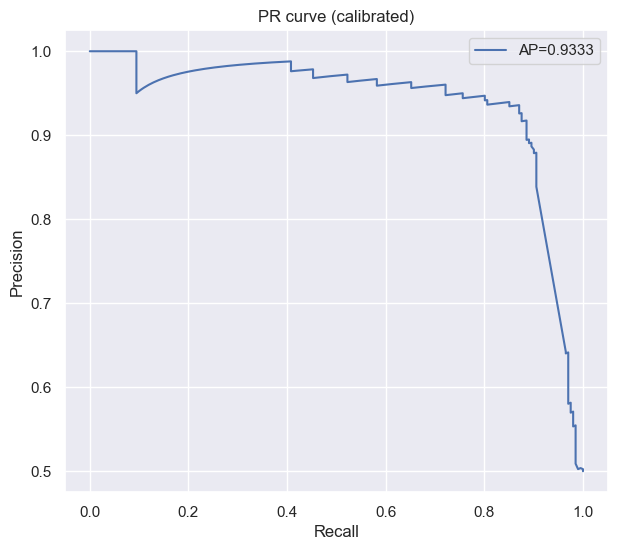

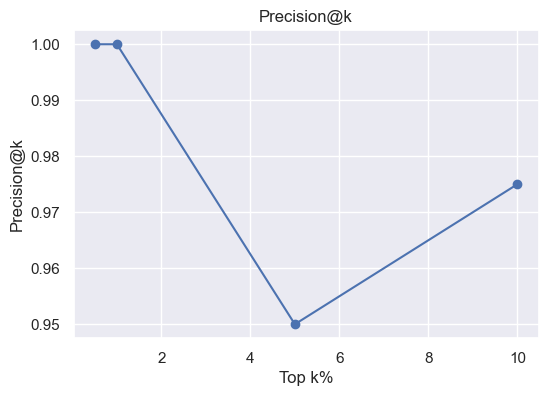

Saved PR and precision@k plots to train_artifacts\pr_curve.png train_artifacts\precision_at_k.png


In [10]:
# Cell 8: PR curve & precision@k plot 保存
from sklearn.metrics import precision_recall_curve
precision, recall, th = precision_recall_curve(y_test, probs_cal)
plt.figure(figsize=(7,6)); plt.plot(recall, precision, label=f'AP={average_precision_score(y_test, probs_cal):.4f}'); plt.xlabel('Recall'); plt.ylabel('Precision'); plt.title('PR curve (calibrated)'); plt.legend(); plt.grid(True); plt.savefig(PR_PNG); plt.show()

pk = precision_at_k_vals(y_test.reset_index(drop=True), pd.Series(probs_cal))
plt.figure(figsize=(6,4)); plt.plot(pk['k_frac']*100, pk['precision'], marker='o'); plt.xlabel('Top k%'); plt.ylabel('Precision@k'); plt.title('Precision@k'); plt.grid(True); plt.savefig(PREC_AT_K_PNG); plt.show()
print('Saved PR and precision@k plots to', PR_PNG, PREC_AT_K_PNG)


In [12]:
# Cell 9: SHAP 分析（若已安裝 shap）
if not SHAP_AVAILABLE:
    print('shap not installed; to enable shap analysis: pip install shap')
else:
    import shap
    # sample to speed up
    sample_X = X_train.sample(n=min(1000, len(X_train)), random_state=RANDOM_STATE)
    # get inner clf from calibrated pipeline
    inner_clf = calib if 'calib' in globals() else best_estimator
    try:
        if 'XGB' in str(type(inner_clf)) or 'LGBM' in str(type(inner_clf)) or 'RandomForest' in str(type(inner_clf)):
            explainer = shap.TreeExplainer(inner_clf)
        else:
            explainer = shap.LinearExplainer(inner_clf, sample_X, feature_perturbation='sampling')
        shap_values = explainer.shap_values(sample_X)
        # summary plot
        plt.figure(figsize=(8,6))
        try:
            shap.summary_plot(shap_values, sample_X, show=False)
            plt.tight_layout()
            plt.savefig(SHAP_PNG, bbox_inches='tight')
            print('Saved SHAP summary to', SHAP_PNG)
        except Exception as e:
            print('Could not produce SHAP summary plot:', e)
    except Exception as e:
        print('SHAP explainer error:', e)


SHAP explainer error: feature_perturbation must be one of 'interventional' or 'correlation_dependent'


In [13]:
# Cell 10: 儲存 metadata.json（model info + metrics + feature list + timestamps）
metadata = {
    'created_at': time.strftime('%Y-%m-%d %H:%M:%S', time.gmtime()),
    'model_path': MODEL_PATH,
    'calibrated_model_path': CALIB_MODEL_PATH,
    'best_model_name': best_name if 'best_name' in globals() else None,
    'cv_ap': float(best_score) if 'best_score' in globals() else None,
    'test_ap': float(ap_test) if 'ap_test' in globals() else None,
    'test_roc_auc': float(roc_test) if 'roc_test' in globals() else None,
    'n_train': int(len(X_train)) if 'X_train' in globals() else None,
    'n_test': int(len(X_test)) if 'X_test' in globals() else None,
    'feature_count': len(feature_cols) if 'feature_cols' in globals() else None,
    'feature_list': feature_cols if 'feature_cols' in globals() else None,
    'notes': 'You may add git commit id or notebook version here for full provenance.'
}
with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)
print('Saved metadata to', METADATA_PATH)


Saved metadata to train_artifacts\metadata.json
